# PA3 - NanoGPT Implementation
## TOTAL MARKS: 100





# NanoGPT Implementation
This notebook is an adaptation from Andrej Karpathy's [nano-scale GPT](https://github.com/karpathy/nanoGPT).

In this notebook we will implement a nano version of GPT in detail and train it on The Tragedy of Coriolanus, a work of Shakespeare.

In the end, our model will be language model that, given an input sentence, will predict the next characters mimicking Shakespeare's writting style.

In [43]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
device = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)

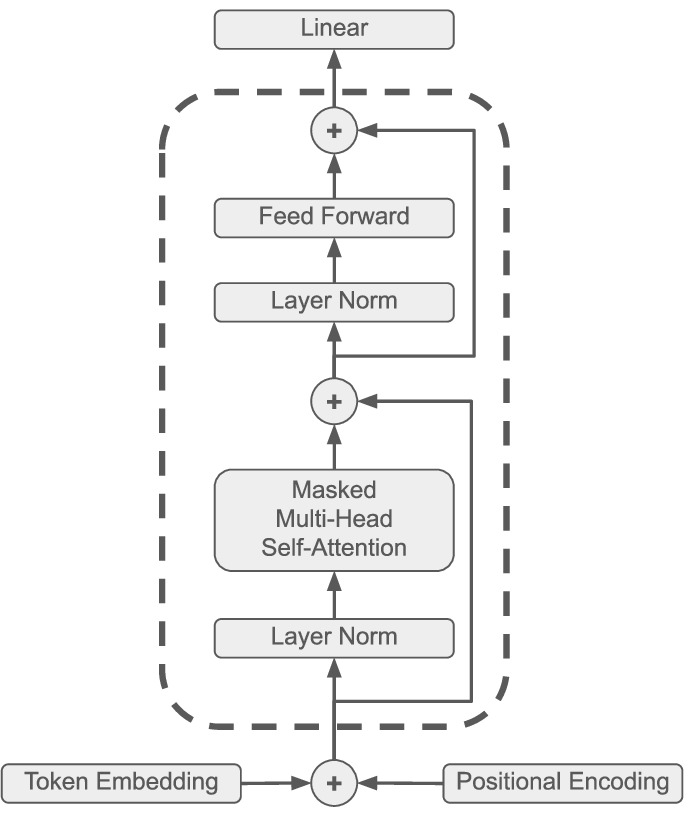

# Input Text
## Loading and Pre-processing

In [44]:
import requests
data_url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
text = requests.get(data_url).text

In [45]:
import os, re

nl = "\n"
print("----Before cleaning\n")
print(f"Number of characters: {len(text)} | lines: {text.count(nl)}")
text = " ".join(text.splitlines())
text = re.sub("\s\s+", "\n", text)
vocab = sorted(list(set(text)))
print("Vocab:", repr("".join(vocab)))
print("len vocab:", len(vocab))
text = text.translate(str.maketrans("ÀÂÇÈÉÊÔàâçèéêëîïñôöùûü", "AACEEEOaaceeeeiinoouuu", "\"«°º»_/*+()"))
text = text.replace("æ", "ae")
print("\n----After cleaning\n")


nl = "\n"
print(f"Numbre of characters: {len(text)} | lines: {text.count(nl)}")
print("----------")
print("Sample text:\n", text[:1000])
print("----------")

vocab = sorted(list(set(text)))
print("Vocab:", repr("".join(vocab)))
VOCAB_SIZE = len(vocab)
print("len vocab:", VOCAB_SIZE)

----Before cleaning

Number of characters: 1115394 | lines: 40000
Vocab: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
len vocab: 65

----After cleaning

Numbre of characters: 1108152 | lines: 7236
----------
Sample text:
 First Citizen: Before we proceed any further, hear me speak.
All: Speak, speak.
First Citizen: You are all resolved rather to die than to famish?
All: Resolved. resolved.
First Citizen: First, you know Caius Marcius is chief enemy to the people.
All: We know't, we know't.
First Citizen: Let us kill him, and we'll have corn at our own price. Is't a verdict?
All: No more talking on't; let it be done: away, away!
Second Citizen: One word, good citizens.
First Citizen: We are accounted poor citizens, the patricians good. What authority surfeits on would relieve us: if they would yield us but the superfluity, while it were wholesome, we might guess they relieved us humanely; but they think we are too dear: the leanness that afflicts us, the object o

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Mr Laptop point\AppData\Local\Temp\ipykernel_29452\1796116659.py:7: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub("\s\s+", "\n", text)


## Tokenizer [5 Marks]
Character level tokenizer

In [46]:
stoi = {c:i for i,c in enumerate(vocab)}
itos = {i:c for i,c in enumerate(vocab)}

# TODO: Implement encode(s) -> list[int]
def encode(s):
    return [stoi[c] for c in s]
# TODO: Implement decode(l) -> string
def decode(l):
    return ''.join([itos[i] for i in l])

Testing if our tokenizer works on the dataset

In [47]:
data = torch.tensor(encode(text))
print(data.shape, data.dtype)
data[:64]

torch.Size([1108152]) torch.int64


tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  1, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0, 13, 50, 50])

Splitting the dataset

In [48]:
n = int(0.9*len(data))
train_data = data[:n]
val_data = data[n:]

print(f"Train dataset len: {len(train_data)} | val: {len(val_data)}")

Train dataset len: 997336 | val: 110816


## Dataloader [5 Marks]
Dataloader function and checking if it works.
Given a list of tokens, predict the next one.

In [ ]:
batch_size = 4  # size of a batch
# define the context length or the size that we will be feeding into the transformer at a given time
ctx_size = 8    # context used to predict next character

def get_batch(split, device):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - ctx_size, (batch_size,))

    # TODO: construct x (inputs) of shape (B, T)
    x = torch.stack([data[i:i+ctx_size] for i in ix])
    # TODO: construct y (targets) shifted by 1
    y = torch.stack([data[i+1:i+1+ctx_size] for i in ix])

    return x.to(device), y.to(device)

xb, yb = get_batch('train', device)
print('inputs:', xb.shape)
print(xb)
print('targets:', yb.shape)
print(yb)

print('----')

for b in range(batch_size):
    for t in range(ctx_size):
        context = xb[b,:t+1].detach().cpu().numpy()
        target = yb[b,t].detach().cpu().numpy()
        print(f"when input is {context} the target: {target}")

# we want the transformer to be used to seeing as little context as 1 all the way up to 8

inputs: torch.Size([4, 8])
tensor([[43, 51,  1, 39, 56, 43,  1, 52],
        [46, 39, 54, 54, 47, 52, 43, 57],
        [27, 30, 23, 10,  1, 32, 46, 43],
        [52, 45, 59, 43,  6,  1,  5, 13]])
targets: torch.Size([4, 8])
tensor([[51,  1, 39, 56, 43,  1, 52, 43],
        [39, 54, 54, 47, 52, 43, 57, 57],
        [30, 23, 10,  1, 32, 46, 43, 52],
        [45, 59, 43,  6,  1,  5, 13, 52]])
----
when input is [43] the target: 51
when input is [43 51] the target: 1
when input is [43 51  1] the target: 39
when input is [43 51  1 39] the target: 56
when input is [43 51  1 39 56] the target: 43
when input is [43 51  1 39 56 43] the target: 1
when input is [43 51  1 39 56 43  1] the target: 52
when input is [43 51  1 39 56 43  1 52] the target: 43
when input is [46] the target: 39
when input is [46 39] the target: 54
when input is [46 39 54] the target: 54
when input is [46 39 54 54] the target: 47
when input is [46 39 54 54 47] the target: 52
when input is [46 39 54 54 47 52] the target: 43

**Detailed Implementation**

## Mathematical trick in self-attention

We want self attention for 'the quick brown'.

"the": [2., 7.]

"quick": [6., 4.]

"brown": [6., 5.]

Input:

[[2., 7.],

 [6., 4.],

 [6., 5.]]


Desired Output:

[[2, 7],

 [4, 5.5],

 [4.67, 5.33]]

One way is to setup a loop to sum the values and then divide.

###Can we do better?


**a**

-> Take a lower triangular matrix **a**:


[[1.0000, 0.0000, 0.0000],

[1.000, 1.000, 0.0000],

[1.000, 1.000, 1.000]]


-> divide by the sum of each row


[[1.0000, 0.0000, 0.0000],

[0.5000, 0.5000, 0.0000],

[0.3333, 0.3333, 0.3333]]



multiply with b:

**b**

[[2., 7.],

[6., 4.],

[6., 5.]]


**result**

[[2, 7],

[4, 5.5],

[4.67, 5.33]]

In [50]:
# import torch
# torch.manual_seed(42)
# xbow = torch.zeros((B,T,C))
# for b in range(B):
#     for t in range(T):
#         xprev = x[b,:t+1] # (t,C)
#         xbow[b,t] = torch.mean(xprev, 0)

In [51]:
# toy example illustrating how matrix multiplication can be used for a "weighted aggregation"
import torch
from torch.nn import functional as F
torch.manual_seed(42)
a = torch.tril(torch.ones(3, 3))
a = a / torch.sum(a, 1, keepdim=True)
b = torch.randint(0,10,(3,2)).float()
c = a @ b
print('a=')
print(a)
print('--')
print('b=')
print(b)
print('--')
print('c=')
print(c)

a=
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
--
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
--
c=
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


In [52]:
# Self-attention!
import torch
import torch.nn as nn
from torch.nn import functional as F

torch.manual_seed(1337)

B,T,C = 4, 8, 16 # batch,ctx,vocab
x = torch.randn((B,T,C)) # batch,ctx,vocab

head_embed_size = 32
key = nn.Linear(C, head_embed_size, bias=False)
query = nn.Linear(C, head_embed_size, bias=False)
value = nn.Linear(C, head_embed_size, bias=False)

k = key(x) # batch,ctx,vocab -> batch,ctx,head_size
q = query(x) # batch,ctx,vocab -> batch,ctx,head_size
mask = q @ k.transpose(-2, -1) # batch,ctx,head_size @ batch,head_size,ctx -> batch,ctx,ctx

tril = torch.tril(torch.ones((T,T))) # ctx,ctx
mask = mask.masked_fill(tril == 0, float("-inf")) # ctx,ctx
mask = F.softmax(mask, dim=-1) # ctx,ctx

v = value(x) # batch,ctx,vocab -> batch,ctx,head_size
out = mask @ v # ctx,ctx * batch,ctx,head_size -> batch,ctx,head_size

out.shape

torch.Size([4, 8, 32])

Notes:
- Attention is a **communication mechanism**. Can be seen as nodes in a directed graph looking at each other and aggregating information with a weighted sum from all nodes that point to them, with data-dependent weights.
- There is no notion of space. Attention simply acts over a set of vectors. This is why we need to positionally encode tokens.
- Each example across batch dimension is of course processed completely independently and never "talk" to each other
- In an "encoder" attention block just delete the single line that does masking with `tril`, allowing all tokens to communicate. This block here is called a "decoder" attention block because it has triangular masking, and is usually used in autoregressive settings, like language modeling.
- "self-attention" just means that the keys and values are produced from the same source as queries. In "cross-attention", the queries still get produced from x, but the keys and values come from some other, external source (e.g. an encoder module).

## Self-Attention

### Self-Attention mechanism

In [53]:
B,T,C = 4, 8, 16 # batch,ctx,vocab
x = torch.randn((B,T,C)) # batch,ctx,vocab

head_embed_size = 32
key = nn.Linear(C, head_embed_size, bias=False)
query = nn.Linear(C, head_embed_size, bias=False)
value = nn.Linear(C, head_embed_size, bias=False)

k = key(x) # batch,ctx,vocab -> batch,ctx,head_size
q = query(x) # batch,ctx,vocab -> batch,ctx,head_size
mask = q @ k.transpose(-2, -1) # batch,ctx,head_size @ batch,head_size,ctx -> batch,ctx,ctx

tril = torch.tril(torch.ones((T,T))) # ctx,ctx
mask = mask.masked_fill(tril == 0, float("-inf")) # ctx,ctx
mask = F.softmax(mask, dim=-1) # ctx,ctx

v = value(x) # batch,ctx,vocab -> batch,ctx,head_size
out = mask @ v # ctx,ctx * batch,ctx,head_size -> batch,ctx,head_size

out.shape

torch.Size([4, 8, 32])

VOCAB_SIZE: Number of unique characters in your vocabulary.

embed_size: Dimensionality of the character embeddings.

ctx_size: Maximum length of the input sequence the model can handle.

batch_size: The number of training examples utilized in one iteration (forward and backward pass) of model training.

### Self-Attention Head [10 Marks]

In [54]:
class Head(nn.Module):
    def __init__(self, embed_size, head_embed_size, dropout=0):
        super().__init__()
        self.key = nn.Linear(embed_size, head_embed_size, bias=False)
        self.query = nn.Linear(embed_size, head_embed_size, bias=False)
        self.value = nn.Linear(embed_size, head_embed_size, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # TODO: Implement masked self-attention
        K = self.key(x)
        Q = self.query(x)
        V = self.value(x)
        wei = Q @ K.transpose(-2, -1) * (K.shape[-1] ** -0.5)
        tril = torch.tril(torch.ones(wei.shape[-2:])).to(wei.device)
        wei = wei.masked_fill(tril == 0, float("-inf"))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        out = wei @ V
        return out


### Multiheaded Self-Attention [10 Marks]

In [55]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, embed_size, dropout=0):
        super().__init__()
        self.heads = nn.ModuleList([Head(embed_size, embed_size // num_heads) for _ in range(num_heads)])
        self.proj = nn.Linear(embed_size, embed_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # TODO: Apply all heads, concatenate, project, dropout
        out = torch.cat([h(x) for h in self.heads], dim=-1)  # (B, T, C)
        out = self.dropout(self.proj(out))  # (B, T, C)
        return out
        


## Transformer Block [15 Marks]

In [56]:
class Block(nn.Module):
    def __init__(self, num_heads, embed_size, dropout=0):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_size)
        self.ln2 = nn.LayerNorm(embed_size)
        self.mha = MultiHeadAttention(num_heads, embed_size, dropout)
        self.ff = nn.Sequential(
            nn.Linear(embed_size, 4 * embed_size),
            nn.ReLU(),
            nn.Linear(4 * embed_size, embed_size),
        )

    def forward(self, x):
        # TODO: Implement Transformer block with residual connections
        x = x + self.mha(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


## GPT Model [40 Marks]

In [ ]:
# Model Hyperparameters
embed_size = 32
num_heads = 1
num_layers = 1
dropout = 0

# Training Hyperparameters
batch_size = 64
ctx_size = 256
embed_size = 384
num_heads = 6
num_layers = 6

lr = 3e-4

class LanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, embed_size)
        self.pos_embedding = nn.Embedding(ctx_size, embed_size)
        # Chain multiple layers together in a specific order.
        self.blocks = nn.Sequential(*[Block(num_heads, embed_size) for _ in range(num_layers)])
        self.ln = nn.LayerNorm(embed_size)
        self.ff = nn.Linear(embed_size, VOCAB_SIZE)

    def forward(self, inputs, targets=None):
        # TODO: Compute token embeddings
        tok_emb = self.embedding(inputs)

        # TODO: Compute positional embeddings
        pos_emb = self.pos_embedding(torch.arange(inputs.size(1), device=inputs.device))

        # TODO: Add token + positional embeddings
        x = tok_emb + pos_emb

        # TODO: Pass through Transformer blocks
        x = self.blocks(x)

        # TODO: Apply final LayerNorm
        x = self.ln(x)

        # TODO: Project to vocabulary logits
        logits = self.ff(x)

        if targets is None:
            loss = None
        else:
            # TODO: reshape logits and targets for cross-entropy
            B, T, C = logits.shape

            lv = logits.view(B*T, C)
            tv = targets.view(B*T)

            # TODO: compute cross-entropy loss
            loss = F.cross_entropy(lv, tv)

        return logits, loss

    def generate(self, tokens, n=1):
        for _ in range(n):
            logits, _ = self(tokens[:, -ctx_size:])

            # TODO: take last timestep logits
            logits = logits[:, -1, :]

            # TODO: apply softmax
            probs = F.softmax(logits, dim=-1)

            # TODO: sample next token
            next_token = torch.multinomial(probs, num_samples=1)

            tokens = torch.cat((tokens, next_token), dim=1)

        return tokens


model = LanguageModel()
device = "cpu"
model.to(device)

print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

xb, yb = get_batch("train", device)
logits, loss = model(xb, yb)

print("loss:", loss.item())

print(decode(model.generate(torch.ones((1,1), dtype=torch.int64), 64)[0].numpy()))

10.788929 M parameters
loss: 4.354193687438965
 VoBEJCmaKPyEUqE3xGrDRiuky$ MTj?DtxUrUD..g$rPReTDwsl3mwYJ!wJYMZuk


In [58]:
for name, param in model.named_parameters():
    print(f"{str(param.size()):20} {param.numel():10}    {name}")

torch.Size([65, 384])      24960    embedding.weight
torch.Size([256, 384])      98304    pos_embedding.weight
torch.Size([384])           384    blocks.0.ln1.weight
torch.Size([384])           384    blocks.0.ln1.bias
torch.Size([384])           384    blocks.0.ln2.weight
torch.Size([384])           384    blocks.0.ln2.bias
torch.Size([64, 384])      24576    blocks.0.mha.heads.0.key.weight
torch.Size([64, 384])      24576    blocks.0.mha.heads.0.query.weight
torch.Size([64, 384])      24576    blocks.0.mha.heads.0.value.weight
torch.Size([64, 384])      24576    blocks.0.mha.heads.1.key.weight
torch.Size([64, 384])      24576    blocks.0.mha.heads.1.query.weight
torch.Size([64, 384])      24576    blocks.0.mha.heads.1.value.weight
torch.Size([64, 384])      24576    blocks.0.mha.heads.2.key.weight
torch.Size([64, 384])      24576    blocks.0.mha.heads.2.query.weight
torch.Size([64, 384])      24576    blocks.0.mha.heads.2.value.weight
torch.Size([64, 384])      24576    blocks.0.mha.

## Training the Model [15 Marks]

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
steps = 2000

print(f"batch_size={batch_size} ctx_size={ctx_size} embed_size={embed_size} num_heads={num_heads} num_layers={num_layers} dropout={dropout}")

optim = torch.optim.Adam(model.parameters(), lr=lr)

model.to(device)
model.train()

print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

for step in range(steps):
    xb, yb = get_batch('train', device)

    if step % 100 == 0:
        model.eval()
        with torch.no_grad():
            splits = {}
            for split in ['train', 'val']:
                losses = torch.zeros(100)
                for k in range(100):
                    X, y = get_batch(split, device)

                    # TODO: forward pass
                    logits, loss = model(X, y)

                    losses[k] = loss.item()
                splits[split] = losses.mean()

        print(f"Step {step:4}: train loss {splits['train']:.5f} | val loss {splits['val']:.5f}")

        if step % 500 == 0:
            encoded = torch.tensor(encode("Hi"), dtype=torch.int64, device=device).unsqueeze(0)

            # TODO: generate text from model
            generated = model.generate(encoded, n=64)

            print("\t" + decode(generated[0].cpu().numpy()))

        model.train()

    # TODO: forward pass on training batch
    logits, loss = model(xb, yb)

    # TODO: zero gradients
    optim.zero_grad()

    # TODO: backpropagation
    loss.backward()

    # TODO: optimizer step
    optim.step()

print()
print(loss.item())

model.to("cpu")
model.eval()

encoded = torch.tensor(encode("Hi"), dtype=torch.int64).unsqueeze(0)

# TODO: final generation
generated = model.generate(encoded, n=64)

print(decode(generated[0].numpy()))

batch_size=64 ctx_size=256 embed_size=384 num_heads=6 num_layers=6 dropout=0
10.788929 M parameters


KeyboardInterrupt: 